<a href="https://colab.research.google.com/github/KavyaSP2808/AIML-/blob/project/Fundamentals%20of%20Neural%20Networks/CNNs/Image%20Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification with Convolutional Neural Networks (CNNs)

---

## Introduction

**Image Classification** is the task of assigning a label (class) to an image based on its visual content. CNNs are the standard approach for image classification due to their ability to automatically extract **hierarchical features** from images, reducing the need for manual feature engineering.

---

## Key Concepts

### 1. Input Layer
- Accepts raw image data.
- Typically shaped as `(height, width, channels)`; for grayscale images, channels = 1; for RGB images, channels = 3.

### 2. Convolutional Layers
- Apply **filters/kernels** that slide over the image to extract local patterns such as edges, textures, and shapes.
- Multiple filters produce multiple feature maps.
- Example: Detecting vertical or horizontal edges in early layers.

### 3. Activation Function
- Introduces **non-linearity**.
- ReLU (Rectified Linear Unit) is commonly used in CNNs.

### 4. Pooling Layers
- Reduce spatial dimensions of feature maps to **lower computational cost** and **control overfitting**.
- Types:
  - **Max Pooling:** Takes the maximum value from a region.
  - **Average Pooling:** Takes the average value from a region.

### 5. Fully Connected Layers
- Flatten feature maps into a 1D vector.
- Perform **high-level reasoning** to map features to classes.

### 6. Output Layer
- Produces final class predictions.
- For multi-class classification, **softmax activation** is used to output probabilities for each class.

---

## Training Process

1. **Forward Propagation:** Pass images through the network to compute predictions.
2. **Loss Calculation:** Compare predictions with true labels using a loss function (e.g., categorical crossentropy).
3. **Backpropagation:** Compute gradients of the loss with respect to network parameters.
4. **Weight Update:** Update weights using an optimizer (e.g., Adam, SGD).
5. Repeat for multiple **epochs** until the network learns to classify images accurately.

---

## Applications

- Handwritten digit recognition (MNIST)
- Object detection and recognition (CIFAR-10, ImageNet)
- Medical imaging (tumor detection, X-ray classification)
- Facial recognition
- Autonomous vehicles (traffic sign recognition)

---

## Advantages of CNNs for Image Classification

- Automatically **learn spatial features** without manual feature engineering.
- **Parameter sharing** reduces the number of parameters compared to fully connected networks.
- **Hierarchical learning:** Early layers detect simple patterns; deeper layers detect complex structures.
- Works well on large-scale image datasets.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 600s 4us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.2859 - loss: 1.9294 - val_accuracy: 0.4804 - val_loss: 1.4639
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.4760 - loss: 1.4498 - val_accuracy: 0.5534 - val_loss: 1.2980
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5380 - loss: 1.2958 - val_accuracy: 0.6036 - val_loss: 1.1362
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 45ms/step - accuracy: 0.5785 - loss: 1.1868 - val_accuracy: 0.6042 - val_loss: 1.1173
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.6079 - loss: 1.1199 - val_accuracy: 0.6409 - val_loss: 1.0261
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.6270 - loss: 1.0686 - val_accuracy: 0.6602 - val_loss: 0.9763
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.6419 - loss: 1.0147 - val_accuracy: 0.6648 - val_loss: 0.9536
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.6616 - loss: 0.9633 - 

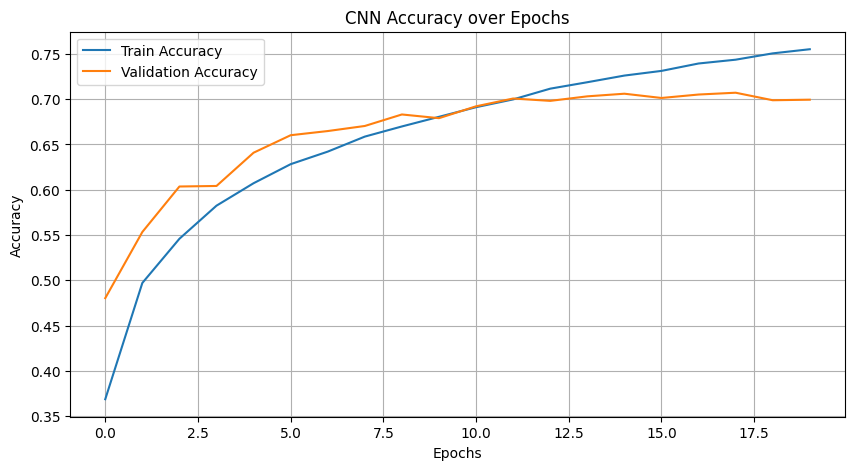

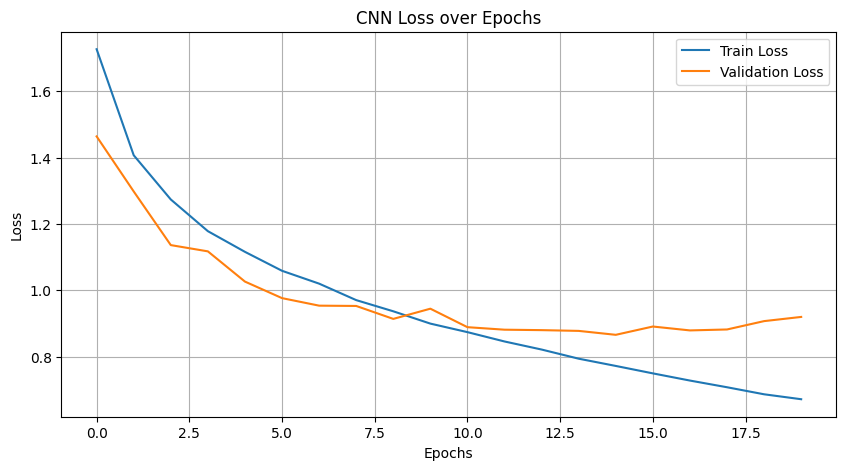

In [3]:
# ==============================
# Image Classification with CNNs - CIFAR-10 Example
# ==============================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load dataset (CIFAR-10)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Preprocess data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

# 6. Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 7. Plot training history
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()